## Questions I Want to Answer

1. Which gender had a higher survival rate?
2. Did ticket class affect a passenger's chance of survival?
3. Did passengers who paid a higher fare survive more often?
4. Are there any missing values, duplicates or outliers in the data?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [2]:
import seaborn as sns
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print("Rows aur Columns:", df.shape)
df.info()

Rows aur Columns: (53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [4]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [5]:
df.duplicated().sum()

np.int64(146)

In [6]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df = df.drop_duplicates()
df["age"] = df["age"].fillna(df["age"].median())
df = df.drop(columns=["deck"], errors="ignore")
df = df.dropna()

print("Rows aur Columns:", df.shape)
df.isnull().sum()

Rows aur Columns: (782, 14)


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [7]:
df.groupby("sex")["survived"].mean()

,survived
sex,
female,0.738832
male,0.215886


In [8]:

df.groupby("pclass")["survived"].mean()


,survived
pclass,
1,0.627358
2,0.509091
3,0.256790


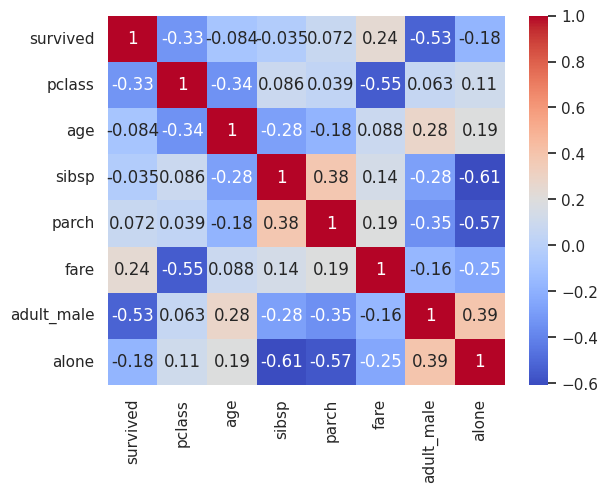

In [9]:
import matplotlib.pyplot as plt
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

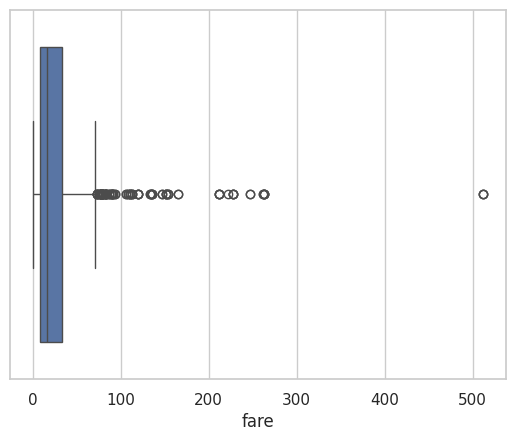

In [10]:
sns.boxplot(x=df["fare"])
plt.show()

## Hypothesis Test 1: Gender and Survival

**Question:** Is there a relationship between a passenger's gender and their survival?

**Null Hypothesis (H0):** Gender and survival are independent (no relationship).

**Alternative Hypothesis (H1):** Gender and survival are related.

**Test used:** Chi-Square Test of Independence, because both variables (sex and survived) are categorical.

**Significance level:** 0.05

In [11]:
from scipy import stats

table = pd.crosstab(df["sex"], df["survived"])
chi2, p, dof, exp = stats.chi2_contingency(table)
print("p-value:", p)

p-value: 2.371774134199127e-46


**Result:** The p-value is ___ (jo output aaya wo likho).

**Conclusion:** Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant relationship between gender and survival. Female passengers were much more likely to survive than male passengers.

## Hypothesis Test 2: Fare and Survival

**Question:** Did passengers who survived pay a different average fare than those who did not?

**Null Hypothesis (H0):** The average fare of survivors and non-survivors is the same.

**Alternative Hypothesis (H1):** The average fare of survivors and non-survivors is different.

**Test used:** Independent Two-Sample T-Test (Welch's), because we are comparing the means of two groups on a numerical variable.

**Significance level:** 0.05


In [12]:
survived = df[df["survived"] == 1]["fare"]
died = df[df["survived"] == 0]["fare"]

t, p = stats.ttest_ind(survived, died, equal_var=False)
print("p-value:", p)
print("Survivors avg fare:", survived.mean())
print("Non-survivors avg fare:", died.mean())

p-value: 6.8492961482274e-10
Survivors avg fare: 49.89275794392523
Non-survivors avg fare: 23.944530585683296


**Result:** The p-value is 6.85e-10, which is far below 0.05. The average fare of survivors was 49.89, while the average fare of non-survivors was 23.94.

**Conclusion:** Since the p-value is less than 0.05, we reject the null hypothesis. Survivors paid a significantly higher fare than non-survivors. This suggests that passengers with expensive (1st class) tickets had a better chance of survival.

In [13]:
df.groupby("sex")["survived"].mean()

,survived
sex,
female,0.738832
male,0.215886


In [14]:
df.groupby("pclass")["survived"].mean()

,survived
pclass,
1,0.627358
2,0.509091
3,0.256790


Key Findings (EDA Summary)

Gender: Female passengers had a survival rate of 73.9%, compared to only 21.6% for males.

Ticket class: 1st class passengers had the highest survival rate (62.7%), while 3rd class had the lowest (___%).

Fare: Survivors paid an average fare of 49.89, more than double the 23.94 paid by non-survivors.

Outliers: A few passengers paid very high fares (up to about 500). These are genuine luxury tickets, so they were kept in the data.

Hypothesis tests: Both tests were statistically significant (p < 0.05). Gender and survival are strongly related (p = 2.37e-46), and survivors paid a significantly higher fare (p = 6.85e-10).